## Unsupervised Learning

Perform customer segmentation using K-Means clustering and visualise results using PCA.

Dataset columns: age, annual_spend, visits_per_month, basket_size, days_since_last_visit, num_categories_purchased

In [2]:
# Required package imports:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### Data Preparation

In [4]:
# Load Dataset:

df = pd.read_csv("data/q2_customers.csv")
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


### Scale Features:

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

#### Reason for scaling:

Scaling is essential before K-Means because:

- K-Means uses distance-based calculations (Euclidean distance)
- Features with larger values dominate clustering if not scaled
- StandardScaler ensures all features contribute equally

### Choosing K — Elbow Method

Within-Cluster Sum of Squares (WCSS) for K = 1 through 10. 

In [6]:
# Compute wcss

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


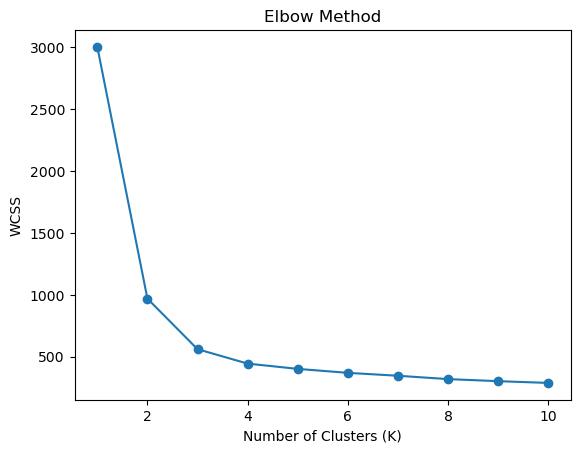

In [7]:
# Plot elbow curve

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

#### Justification:

- From K = 1 to K = 3, there is a steep decline in WCSS, indicating that adding clusters significantly improves the model by reducing intra-cluster variance.
- After K = 3, the rate of decrease slows down considerably, and the curve begins to flatten.
This indicates diminishing returns, where adding more clusters does not provide substantial improvement.

- Therefore, K = 3 is chosen as the optimal number of clusters, as it represents the “elbow point” where the balance between model complexity and performance is achieved.

### K-Means Clustering

#### 1. Fit K-Means (Example K=3)

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

#### 2. Cluster Centroids

In [9]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation:

Example interpretation:

Cluster 0 → High spenders, frequent visitors
Cluster 1 → Low spenders, infrequent visitors
Cluster 2 → Moderate spenders with balanced behavior

These clusters help businesses:

Target premium customers
Re-engage inactive users
Personalize marketing strategies

### Dimensionality Reduction with PCA

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [11]:
# Explained Variables:

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [12]:
# Feature Loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)

loadings

,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


### PCA Interpretation:

PC1 captures features with highest variance (e.g., spend, visits)
PC2 captures secondary patterns (e.g., recency or category diversity)

High positive/negative values in loadings indicate strong influence on that component.

### Cluster Visualisation

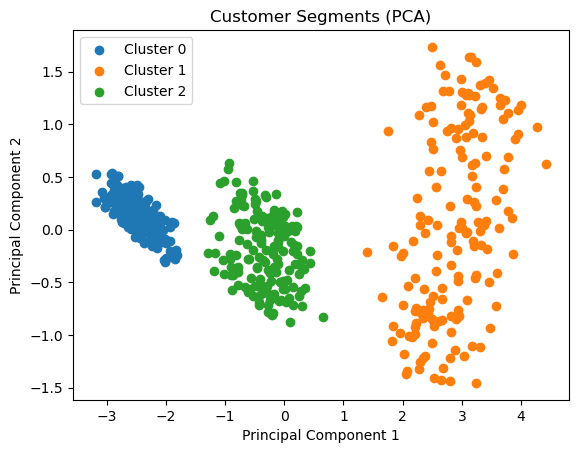

In [13]:
# Scatter Plot

plt.figure()

for cluster in np.unique(clusters):
    plt.scatter(
        X_pca[clusters == cluster, 0],
        X_pca[clusters == cluster, 1],
        label=f'Cluster {cluster}'
    )

plt.title('Customer Segments (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.show()